# Data Collection Pipeline — CC-NEWS

**Project:** SPZ — Geographic Bias in Pre-Trained Sentiment Classifiers

**Author:** Rezvaneh Mousavi | JLU Giessen | M.Sc. Data Analytics

**Supervisor:** Prof. Dr. Stefan Hennemann

---

**Purpose of this notebook:**

This notebook collects English-language news articles from the Common Crawl News (CC-NEWS) archive and assigns an initial country-of-publication label based on the article's source domain. This constitutes the first of three independent geographic assignment methods used in this study (URL-based, NER-based, and manual annotation).

**Pipeline overview:**

1. Download WARC archive files from CC-NEWS to temporary storage
2. Extract article text from raw HTML using trafilatura
3. Filter for English-language articles using langdetect
4. Remove non-news domains via blacklist
5. Assign country of publication based on a curated domain-to-country mapping
6. Save results to Google Drive

**Data persistence:** Each processing stage saves its output to Google Drive. If the Colab session expires, re-running a cell will load the existing output rather than reprocessing from scratch.

---
## 0. Setup and Configuration

In [10]:
# Install required packages:
# warcio       - reads WARC (Web ARChive) files record by record
# trafilatura  - extracts main article text from raw HTML, removing navigation, ads, footers
# langdetect   - statistical language identification
# tldextract   - decomposes URLs into subdomain, domain, and suffix components
#                e.g. "www.bbc.co.uk" -> subdomain="www", domain="bbc", suffix="co.uk"

!pip install -q warcio trafilatura langdetect tldextract

In [11]:
import os
import gzip
import requests
import pandas as pd
from io import BytesIO
from warcio.archiveiterator import ArchiveIterator
from trafilatura import extract
from langdetect import detect, LangDetectException
import tldextract
from datetime import datetime

print('All imports loaded successfully.')

All imports loaded successfully.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# --- Path configuration ---
# This path assumes you have added a shortcut to the "UNI" folder in My Drive.
# To do this: Google Drive > Shared with me > right-click UNI > Organise > Add shortcut to Drive > My Drive
#
# If your folder structure differs, adjust DRIVE_BASE accordingly.

DRIVE_BASE = '/content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule'
DATA_RAW = f'{DRIVE_BASE}/data/raw'
DATA_PROCESSED = f'{DRIVE_BASE}/data/processed'

for folder in [DATA_RAW, DATA_PROCESSED]:
    os.makedirs(folder, exist_ok=True)

assert os.path.exists(DRIVE_BASE), f'Path not found: {DRIVE_BASE} -- check your Drive shortcut.'
print(f'Working directory: {DRIVE_BASE}')
print(f'Data (raw):       {DATA_RAW}')
print(f'Data (processed): {DATA_PROCESSED}')

Working directory: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule
Data (raw):       /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw
Data (processed): /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed


In [14]:
# --- Collection parameters ---

TARGET_YEAR = '2025'
TARGET_MONTH = '01'          # January 2025
MAX_WARC_FILES = 3           # Number of WARC files to process (start small, increase as needed)
MIN_ARTICLE_LENGTH = 200     # Minimum character count to consider a valid article

---
## 1. Retrieve WARC File Listing

CC-NEWS organises its archive by month. Each month has a listing file (`warc.paths.gz`) that contains the paths to all WARC files collected during that period. Each WARC file is a compressed archive holding thousands of individual web page captures from news sites worldwide.

Reference: https://data.commoncrawl.org/crawl-data/CC-NEWS/index.html

In [15]:
listing_url = f'https://data.commoncrawl.org/crawl-data/CC-NEWS/{TARGET_YEAR}/{TARGET_MONTH}/warc.paths.gz'
print(f'Requesting WARC listing: {listing_url}')

response = requests.get(listing_url)
response.raise_for_status()

warc_paths = gzip.decompress(response.content).decode('utf-8').strip().split('\n')
print(f'Available WARC files for {TARGET_YEAR}/{TARGET_MONTH}: {len(warc_paths)}')
print(f'Will process: {min(MAX_WARC_FILES, len(warc_paths))}')

Requesting WARC listing: https://data.commoncrawl.org/crawl-data/CC-NEWS/2025/01/warc.paths.gz
Available WARC files for 2025/01: 403
Will process: 3


---
## 2. Pipeline Functions

The following cells define the core processing functions. They are executed in Section 3.

### 2.1 WARC Download and Article Extraction

A WARC file contains sequential records, each representing one HTTP transaction captured by the crawler. We filter for `response` records with HTML content, then use `trafilatura` to extract the main article body. Trafilatura is designed specifically for news and web content extraction: it identifies the primary content area and strips navigation elements, advertisements, and boilerplate.

In [16]:
def download_warc(warc_path):
    """Download a WARC file from Common Crawl into memory."""
    url = f'https://data.commoncrawl.org/{warc_path}'
    filename = warc_path.split('/')[-1]
    print(f'  Downloading {filename}...')
    response = requests.get(url, stream=True)
    response.raise_for_status()
    size_mb = len(response.content) / (1024 * 1024)
    print(f'  Size: {size_mb:.1f} MB')
    return BytesIO(response.content)

In [17]:
def extract_articles_from_warc(warc_stream, min_length=MIN_ARTICLE_LENGTH):
    """
    Extract article text, URL, and capture date from a WARC file.

    Processing logic:
    - Only HTTP response records are considered (not requests or metadata).
    - Only text/html content types are processed (images, PDFs, etc. are skipped).
    - trafilatura handles the HTML-to-text conversion.
    - Articles shorter than min_length characters are discarded, as these are
      typically navigation pages, error pages, or incomplete extractions.
    """
    articles = []
    skipped_non_html = 0
    skipped_short = 0
    errors = 0

    for record in ArchiveIterator(warc_stream):
        if record.rec_type != 'response':
            continue

        content_type = record.http_headers.get_header('Content-Type') or ''
        if 'text/html' not in content_type:
            skipped_non_html += 1
            continue

        try:
            url = record.rec_headers.get_header('WARC-Target-URI')
            date = record.rec_headers.get_header('WARC-Date')
            html = record.content_stream().read().decode('utf-8', errors='replace')
            text = extract(html)

            if text and len(text) >= min_length:
                articles.append({'url': url, 'date': date, 'text': text})
            else:
                skipped_short += 1
        except Exception:
            errors += 1
            continue

    print(f'  Extracted: {len(articles)} articles '
          f'| {skipped_non_html} non-HTML | {skipped_short} too short | {errors} errors')
    return articles

### 2.2 Language Detection and Domain Filtering

Two-stage filtering is applied:

1. **Language detection** via `langdetect`, applied to the first 500 characters of each article. This is sufficient for reliable identification and avoids unnecessary computation on full texts.

2. **Domain blacklist** to remove non-news domains (social media, aggregators, e-commerce) that pass the language filter. This approach was validated in the previous project, where language detection alone proved insufficient for clean filtering.

In [18]:
def detect_language(text):
    """Return ISO 639-1 language code, or None if detection fails."""
    try:
        return detect(text[:500])
    except LangDetectException:
        return None

In [19]:
DOMAIN_BLACKLIST = {
    # Social media and user-generated content
    'reddit.com', 'twitter.com', 'x.com', 'facebook.com',
    'youtube.com', 'instagram.com', 'tiktok.com',
    # News aggregators and portals
    'news.google.com', 'news.yahoo.com', 'msn.com',
    'flipboard.com', 'apple.news',
    # Weather and utilities
    'weather.com', 'accuweather.com',
    # Non-news
    'wikipedia.org', 'amazon.com', 'ebay.com',
    'pinterest.com', 'linkedin.com',
}


def is_blacklisted(url):
    """Check whether a URL belongs to a blacklisted domain."""
    try:
        ext = tldextract.extract(url)
        return ext.registered_domain in DOMAIN_BLACKLIST
    except Exception:
        return True  # reject unparseable URLs

### 2.3 URL-Based Country Assignment (Method 1 of 3)

This is the first and simplest of the three geographic assignment methods used in this study. It maps each article's source domain to a country of publication using a curated lookup table.

**What it captures:** Where the article was *published* (i.e., the news organisation's country of origin).

**What it does not capture:** What country the article is *about*. For example, a BBC article reporting on Indian elections would be labelled UK by this method. The NER + Geonames approach (Method 2, Notebook 02) addresses this distinction.

**Limitations:**
- Only works for domains explicitly listed in the mapping.
- Articles from unlisted domains are marked as unassigned, not discarded.
- The mapping is expanded iteratively based on the frequency distribution of unassigned domains.

Country selection is data-driven: the initial mapping covers five target regions (US, UK, Australia, India, Germany), but the final set of included countries depends on which sources yield sufficient article counts in the data.

In [20]:
DOMAIN_TO_COUNTRY = {
    # --- United States ---
    'nytimes.com': 'US',
    'washingtonpost.com': 'US',
    'apnews.com': 'US',
    'foxnews.com': 'US',
    'cnn.com': 'US',
    'usatoday.com': 'US',
    'latimes.com': 'US',
    'nbcnews.com': 'US',
    'cbsnews.com': 'US',
    'npr.org': 'US',
    'politico.com': 'US',
    'thehill.com': 'US',
    'reuters.com': 'US',
    'bloomberg.com': 'US',

    # --- United Kingdom ---
    'bbc.co.uk': 'UK',
    'bbc.com': 'UK',
    'theguardian.com': 'UK',
    'telegraph.co.uk': 'UK',
    'independent.co.uk': 'UK',
    'dailymail.co.uk': 'UK',
    'mirror.co.uk': 'UK',
    'thetimes.co.uk': 'UK',
    'sky.com': 'UK',

    # --- Australia ---
    'abc.net.au': 'AU',
    'smh.com.au': 'AU',
    'news.com.au': 'AU',
    'theaustralian.com.au': 'AU',
    'sbs.com.au': 'AU',
    '9news.com.au': 'AU',

    # --- India ---
    'thehindu.com': 'IN',
    'ndtv.com': 'IN',
    'hindustantimes.com': 'IN',
    'indianexpress.com': 'IN',
    'firstpost.com': 'IN',
    'theprint.in': 'IN',
    'scroll.in': 'IN',
    'livemint.com': 'IN',
    'deccanherald.com': 'IN',

    # --- Germany (English-language output) ---
    'dw.com': 'DE',
}

# Some news sources use a subdomain as part of their identity.
# These require a separate lookup that includes the subdomain.
SUBDOMAIN_TO_COUNTRY = {
    'timesofindia.indiatimes.com': 'IN',
    'abcnews.go.com': 'US',
}


def assign_country_by_url(url):
    """
    Map an article's URL to a country of publication.

    Uses a two-pass lookup:
    1. Check the full domain including subdomain (handles cases like
       timesofindia.indiatimes.com where the subdomain is essential).
    2. Check the registered domain only (standard cases like bbc.co.uk).

    Returns a country code (e.g., 'US', 'UK') or None if not in the mapping.
    """
    try:
        ext = tldextract.extract(url)
        registered_domain = ext.registered_domain

        # Pass 1: subdomain-specific lookup
        if ext.subdomain:
            full_domain = f'{ext.subdomain}.{registered_domain}'
            if full_domain in SUBDOMAIN_TO_COUNTRY:
                return SUBDOMAIN_TO_COUNTRY[full_domain]

        # Pass 2: registered domain lookup
        if registered_domain in DOMAIN_TO_COUNTRY:
            return DOMAIN_TO_COUNTRY[registered_domain]

        return None
    except Exception:
        return None


n_domains = len(DOMAIN_TO_COUNTRY) + len(SUBDOMAIN_TO_COUNTRY)
n_countries = len(set(list(DOMAIN_TO_COUNTRY.values()) + list(SUBDOMAIN_TO_COUNTRY.values())))
print(f'Domain mapping loaded: {n_domains} domains across {n_countries} countries')

Domain mapping loaded: 41 domains across 5 countries


### 2.4 Domain Mapping Expansion

After an initial pipeline run with the base mapping from Section 2.3, only 8% of English-language articles could be assigned to a country. An analysis of the most frequent unassigned domains revealed that many belonged to known news outlets from the target countries — particularly Indian sources, which are heavily represented in CC-NEWS.

The following cell extends the mapping with domains identified from the top 50 unassigned list. Domains belonging to countries outside the five target regions (e.g., Nigeria, UAE, Austria) and non-news platforms (e.g., aggregators, photography sites, blog platforms) are excluded.

In [28]:
# --- Domain mapping expansion (based on unassigned domain analysis) ---
# These were identified by examining the top 50 most frequent domains
# among articles not matched by the base mapping in Section 2.3.

DOMAIN_TO_COUNTRY.update({
    # --- United States (expanded) ---
    'etfdailynews.com': 'US',
    'cbssports.com': 'US',
    'rotowire.com': 'US',
    'fastcompany.com': 'US',
    'wkrb13.com': 'US',
    'si.com': 'US',
    'tickerreport.com': 'US',
    'dvidshub.net': 'US',
    'realclearpolitics.com': 'US',
    'comicbook.com': 'US',
    'sportingnews.com': 'US',
    'oursportscentral.com': 'US',
    'newson6.com': 'US',
    'delmarvapublicmedia.org': 'US',
    'kstp.com': 'US',

    # --- India (expanded) ---
    'business-standard.com': 'IN',
    'thehawk.in': 'IN',
    'latestly.com': 'IN',
    'lokmattimes.com': 'IN',
    'indiatimes.com': 'IN',
    'timesnownews.com': 'IN',
    'newindianexpress.com': 'IN',
    'republicworld.com': 'IN',
    'newsdrum.in': 'IN',
    'thehansindia.com': 'IN',
    'telegraphindia.com': 'IN',
    'sakshipost.com': 'IN',
    'etvbharat.com': 'IN',
    'millenniumpost.in': 'IN',
    'indiatvnews.com': 'IN',
    'newsbytesapp.com': 'IN',
    'india.com': 'IN',
    'thestatesman.com': 'IN',
    'dtnext.in': 'IN',
})

print(f'Expanded mapping: {len(DOMAIN_TO_COUNTRY)} domains across {len(set(DOMAIN_TO_COUNTRY.values()))} countries')

Expanded mapping: 73 domains across 5 countries


In [31]:
# --- Second expansion round (from updated unassigned list) ---

DOMAIN_TO_COUNTRY.update({
    # --- Australia (first articles found!) ---
    'thewest.com.au': 'AU',
    'perthnow.com.au': 'AU',

    # --- India ---
    'wionews.com': 'IN',

    # --- United States ---
    'newsday.com': 'US',
})

print(f'Mapping now covers {len(DOMAIN_TO_COUNTRY)} domains across {len(set(DOMAIN_TO_COUNTRY.values()))} countries')

Mapping now covers 77 domains across 5 countries


### 2.5 Reset Country Assignment Checkpoint

The country assignment checkpoint from the previous run used the base mapping only. It must be deleted so that Section 3.3 re-runs with the expanded mapping.

In [43]:
# Delete the old country assignment checkpoint so Section 3.3 re-runs
old_checkpoint = f'{DATA_PROCESSED}/articles_with_country_{TARGET_YEAR}_{TARGET_MONTH}.csv'
if os.path.exists(old_checkpoint):
    os.remove(old_checkpoint)
    print(f'Deleted old checkpoint: {old_checkpoint}')
    print('Section 3.3 will now re-run with expanded mapping.')
else:
    print('No checkpoint found — Section 3.3 will run fresh.')

Deleted old checkpoint: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_country_2025_01.csv
Section 3.3 will now re-run with expanded mapping.


### 2.6 Extended Country Mapping (All Countries)

To allow a data-driven country selection (rather than restricting to five pre-specified regions), all identifiable news domains are assigned a country code regardless of whether they belong to the original target countries. Countries with insufficient article counts will be excluded at the analysis stage. This approach follows the principle that country selection should emerge from the data, with a minimum article threshold for inclusion.

ISO 3166-1 alpha-2 country codes are used throughout (e.g., AE = United Arab Emirates, NG = Nigeria, PK = Pakistan).

In [34]:
# --- Extended mapping: all identifiable countries ---
# Domains from outside the original 5 target countries are included
# to support data-driven country selection at the analysis stage.

DOMAIN_TO_COUNTRY.update({
    # --- United Arab Emirates ---
    'khaleejtimes.com': 'AE',

    # --- Nigeria ---
    'newtelegraphng.com': 'NG',
    'dailytrust.com': 'NG',

    # --- Pakistan ---
    'urdupoint.com': 'PK',

    # --- Austria ---
    'krone.at': 'AT',

    # --- United States (additional) ---
    'mymotherlode.com': 'US',

    # --- United Kingdom (additional) ---
    'tribalfootball.com': 'UK',

    # --- India (additional) ---
    'pinkvilla.com': 'IN',
})

print(f'Mapping now covers {len(DOMAIN_TO_COUNTRY)} domains across {len(set(DOMAIN_TO_COUNTRY.values()))} countries')

Mapping now covers 85 domains across 9 countries


### 2.7 Domain Mapping — Batch 2 (Ranks 1–50 of Remaining Unassigned)

Second round of domain classification after the initial expansion. Notable additions include the first articles from Malaysia, South Korea, South Africa, Qatar, and China. US public radio stations are heavily represented in CC-NEWS.

In [39]:
# --- Batch 2 expansion ---

DOMAIN_TO_COUNTRY.update({
    # --- Malaysia ---
    'malaymail.com': 'MY',

    # --- Pakistan (additional) ---
    'nation.com.pk': 'PK',
    'dunyanews.tv': 'PK',
    'arynews.tv': 'PK',

    # --- South Korea ---
    'donga.com': 'KR',

    # --- South Africa ---
    'briefly.co.za': 'ZA',

    # --- Qatar ---
    'aljazeera.com': 'QA',

    # --- China ---
    'people.cn': 'CN',

    # --- Canada ---
    'leafly.ca': 'CA',

    # --- Nigeria (additional) ---
    'dailypost.ng': 'NG',

    # --- India (additional) ---
    'mid-day.com': 'IN',
    'rediff.com': 'IN',
    'asianetnews.com': 'IN',
    'siasat.com': 'IN',
    'munsifdaily.com': 'IN',
    'deccanchronicle.com': 'IN',

    # --- United Kingdom (additional) ---
    'techbullion.com': 'UK',

    # --- United States (additional — mostly public radio and local TV) ---
    'kyuk.org': 'US',
    'wrkf.org': 'US',
    'wlrn.org': 'US',
    'rivals.com': 'US',
    'nhl.com': 'US',
    'knau.org': 'US',
    'cfpublic.org': 'US',
    'kunr.org': 'US',
    'spokesman.com': 'US',
    'tpr.org': 'US',
    'kesq.com': 'US',
    'kvia.com': 'US',
    'aspenpublicradio.org': 'US',
    'localnews8.com': 'US',
    'kunm.org': 'US',
    'wrvo.org': 'US',
    'keyt.com': 'US',
    'clutchpoints.com': 'US',
    'kbbi.org': 'US',
})

print(f'Mapping now covers {len(DOMAIN_TO_COUNTRY)} domains across {len(set(DOMAIN_TO_COUNTRY.values()))} countries')

Mapping now covers 121 domains across 15 countries


### 2.8 Domain Mapping — Batch 3 (Ranks 51–100 of Remaining Unassigned)

Final expansion round. Notable additions include first articles from Iran, Kenya, Thailand, Singapore, Israel, Fiji, and Zambia. The mapping now covers a broad range of English-language news sources worldwide. Country selection for the final analysis will be determined by a minimum article count threshold after processing additional WARC files.

In [42]:
# --- Batch 3 expansion (final) ---

DOMAIN_TO_COUNTRY.update({
    # --- Iran ---
    'mehrnews.com': 'IR',

    # --- Thailand ---
    'bangkokpost.com': 'TH',

    # --- Kenya ---
    'tuko.co.ke': 'KE',

    # --- Israel ---
    'israelnationalnews.com': 'IL',
    'jpost.com': 'IL',

    # --- Singapore ---
    'channelnewsasia.com': 'SG',

    # --- Fiji ---
    'fbcnews.com.fj': 'FJ',

    # --- Zambia ---
    'zambianobserver.com': 'ZM',

    # --- South Korea (additional) ---
    'joins.com': 'KR',

    # --- United Arab Emirates (additional) ---
    'zawya.com': 'AE',

    # --- Pakistan (additional) ---
    'dawn.com': 'PK',
    'pakistantoday.com.pk': 'PK',

    # --- Nigeria (additional) ---
    'businessday.ng': 'NG',
    'legit.ng': 'NG',
    'thisdaylive.com': 'NG',
    'punchng.com': 'NG',

    # --- South Africa (additional) ---
    'citizen.co.za': 'ZA',

    # --- India (additional) ---
    'newsx.com': 'IN',
    'thefederal.com': 'IN',
    'thesportsrush.com': 'IN',
    'orissapost.com': 'IN',

    # --- United States (additional — public radio and local TV) ---
    'nbcsandiego.com': 'US',
    'wyomingpublicmedia.org': 'US',
    'pressherald.com': 'US',
    'ketr.org': 'US',
    'wuwf.org': 'US',
    'kuaf.com': 'US',
    'kclu.org': 'US',
    'kawc.org': 'US',
    'ctpublic.org': 'US',
    'ksut.org': 'US',
    'krgv.com': 'US',
    'delawarepublic.org': 'US',
    'nhpr.org': 'US',
    'wvpe.org': 'US',
    'boisestatepublicradio.org': 'US',
    'upr.org': 'US',
    'staradvertiser.com': 'US',
    'kyma.com': 'US',
    'kvcrnews.org': 'US',
    'wwno.org': 'US',
    'wbrz.com': 'US',
    'whec.com': 'US',
    'whqr.org': 'US',
})

print(f'Final mapping: {len(DOMAIN_TO_COUNTRY)} domains across {len(set(DOMAIN_TO_COUNTRY.values()))} countries')

Final mapping: 165 domains across 22 countries


---
## 3. Execute Pipeline

### 3.1 WARC Extraction

Each WARC file is downloaded into temporary memory, processed, and discarded. Only the extracted article data is retained. WARC files can be re-downloaded from Common Crawl at any time and do not need to be stored.

In [21]:
raw_output_path = f'{DATA_RAW}/articles_raw_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(raw_output_path):
    print(f'Checkpoint found: {raw_output_path}')
    df_raw = pd.read_csv(raw_output_path)
    print(f'Loaded {len(df_raw)} articles from previous run.')

else:
    print(f'Processing {MAX_WARC_FILES} WARC files from {TARGET_YEAR}/{TARGET_MONTH}\n')

    all_articles = []
    files_to_process = warc_paths[:MAX_WARC_FILES]

    for i, warc_path in enumerate(files_to_process, 1):
        print(f'[{i}/{len(files_to_process)}]')
        warc_stream = download_warc(warc_path)
        articles = extract_articles_from_warc(warc_stream)
        all_articles.extend(articles)
        del warc_stream  # free memory
        print(f'  Cumulative total: {len(all_articles)} articles\n')

    df_raw = pd.DataFrame(all_articles)
    df_raw.to_csv(raw_output_path, index=False)
    print(f'Saved {len(df_raw)} raw articles to {raw_output_path}')

Checkpoint found: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_raw_2025_01.csv
Loaded 73588 articles from previous run.


### 3.2 Language Filtering and Domain Blacklist

In [22]:
eng_output_path = f'{DATA_RAW}/articles_english_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(eng_output_path):
    print(f'Checkpoint found: {eng_output_path}')
    df_eng = pd.read_csv(eng_output_path)
    print(f'Loaded {len(df_eng)} English articles from previous run.')

else:
    print(f'Filtering {len(df_raw)} articles...\n')

    # Stage 1: language detection
    df_raw['lang'] = df_raw['text'].apply(detect_language)
    print('Language distribution (top 10):')
    print(df_raw['lang'].value_counts().head(10).to_string())

    df_eng = df_raw[df_raw['lang'] == 'en'].copy()
    print(f'\nAfter language filter: {len(df_eng)} articles')

    # Stage 2: domain blacklist
    before = len(df_eng)
    df_eng = df_eng[~df_eng['url'].apply(is_blacklisted)].copy()
    print(f'After domain blacklist: {len(df_eng)} articles (removed {before - len(df_eng)})')

    # Extract domain metadata for downstream analysis
    df_eng['registered_domain'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).registered_domain
    )
    df_eng['domain_suffix'] = df_eng['url'].apply(
        lambda u: tldextract.extract(u).suffix
    )
    df_eng = df_eng.drop(columns=['lang'])

    df_eng.to_csv(eng_output_path, index=False)
    print(f'\nSaved {len(df_eng)} English articles to {eng_output_path}')

Checkpoint found: /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/raw/articles_english_2025_01.csv
Loaded 15321 English articles from previous run.


### 3.3 Country Assignment (URL-Based)

In [44]:
country_output_path = f'{DATA_PROCESSED}/articles_with_country_{TARGET_YEAR}_{TARGET_MONTH}.csv'

if os.path.exists(country_output_path):
    print(f'Checkpoint found: {country_output_path}')
    df = pd.read_csv(country_output_path)
    print(f'Loaded {len(df)} articles from previous run.')

else:
    print(f'Assigning countries to {len(df_eng)} articles...\n')

    df_eng['country_url'] = df_eng['url'].apply(assign_country_by_url)

    assigned = df_eng['country_url'].notna().sum()
    unassigned = df_eng['country_url'].isna().sum()
    print(f'Assigned: {assigned} | Unassigned: {unassigned}\n')

    print('Country distribution (assigned articles):')
    print(df_eng['country_url'].value_counts().to_string())

    print(f'\nTop 20 unassigned domains (candidates for expanding the mapping):')
    unassigned_df = df_eng[df_eng['country_url'].isna()]
    print(unassigned_df['registered_domain'].value_counts().head(20).to_string())

    df = df_eng.copy()
    df.to_csv(country_output_path, index=False)
    print(f'\nSaved {len(df)} articles to {country_output_path}')

Assigning countries to 15321 articles...

Assigned: 9180 | Unassigned: 6141

Country distribution (assigned articles):
country_url
IN    4228
US    3310
NG     286
PK     269
UK     227
AE     172
AU     111
KR      67
AT      62
ZA      56
MY      51
IL      50
CA      37
QA      34
CN      34
TH      31
DE      31
KE      30
FJ      27
ZM      24
IR      22
SG      21

Top 20 unassigned domains (candidates for expanding the mapping):
registered_domain
menafn.com               260
goal.com                 178
yahoo.com                150
365project.org           149
com-unik.info             99
substack.com              95
pledgetimes.com           89
the-independent.com       89
radio.net                 86
carpages.ca               60
crimethinc.com            60
einpresswire.com          53
condesan-ecoandes.org     48
forex.com                 40
prnewswire.com            28
redandwhitekop.com        28
allafrica.com             27
thecooldown.com           24
the-express.com     

/tmp/ipykernel_1618/3400586753.py:73: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  registered_domain = ext.registered_domain



Saved 15321 articles to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/articles_with_country_2025_01.csv


---
## 4. Collection Summary

In [24]:
separator = '-' * 50

print(f'COLLECTION SUMMARY: CC-NEWS {TARGET_YEAR}/{TARGET_MONTH}')
print(f'WARC files processed: {MAX_WARC_FILES}')
print(separator)
print(f'Total extracted articles (all languages): {len(df_raw)}')
print(f'English articles (after filtering):       {len(df_eng)}')
print(f'Articles with country assigned:           {df["country_url"].notna().sum()}')
print(f'Articles without country assignment:      {df["country_url"].isna().sum()}')
print(separator)

print(f'\nArticles per country:')
print(df['country_url'].value_counts().to_string())

print(f'\nTop 15 domains in dataset:')
print(df['registered_domain'].value_counts().head(15).to_string())

df['text_length'] = df['text'].str.len()
print(f'\nMean article length (characters) by country:')
country_lengths = df.groupby('country_url')['text_length'].mean().round(0).astype(int)
print(country_lengths.to_string())

COLLECTION SUMMARY: CC-NEWS 2025/01
WARC files processed: 3
--------------------------------------------------
Total extracted articles (all languages): 73588
English articles (after filtering):       15321
Articles with country assigned:           1257
Articles without country assignment:      14064
--------------------------------------------------

Articles per country:
country_url
IN    912
US    174
UK    140
DE     31

Top 15 domains in dataset:
registered_domain
etfdailynews.com         500
livemint.com             454
business-standard.com    428
menafn.com               260
thehawk.in               254
latestly.com             252
hindustantimes.com       250
lokmattimes.com          222
indiatimes.com           216
timesnownews.com         181
goal.com                 178
cbssports.com            158
newindianexpress.com     158
republicworld.com        151
yahoo.com                150

Mean article length (characters) by country:
country_url
DE    3515
IN    2951
UK    5703


In [25]:
# Verify saved files on Drive
print('Files saved to Drive:\n')
for label, path in [('raw', DATA_RAW), ('processed', DATA_PROCESSED)]:
    if os.path.exists(path):
        for f in sorted(os.listdir(path)):
            fpath = os.path.join(path, f)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f'  {label}/{f}  ({size_mb:.1f} MB)')

Files saved to Drive:

  raw/articles_english_2025_01.csv  (53.7 MB)
  raw/articles_raw_2025_01.csv  (256.0 MB)
  processed/articles_with_country_2025_01.csv  (53.7 MB)
  processed/fig06_lead_status_distribution.png  (0.0 MB)
  processed/fig07_lead_length_histogram.png  (0.0 MB)
  processed/fig_article_length_2025_01.png  (0.0 MB)
  processed/fig_country_counts_2025_01.png  (0.0 MB)
  processed/fig_coverage_2025_01.png  (0.0 MB)
  processed/fig_lead_length_2025_01.png  (0.0 MB)
  processed/fig_top_domains_2025_01.png  (0.1 MB)
  processed/lead_quality_2025_01.png  (0.1 MB)


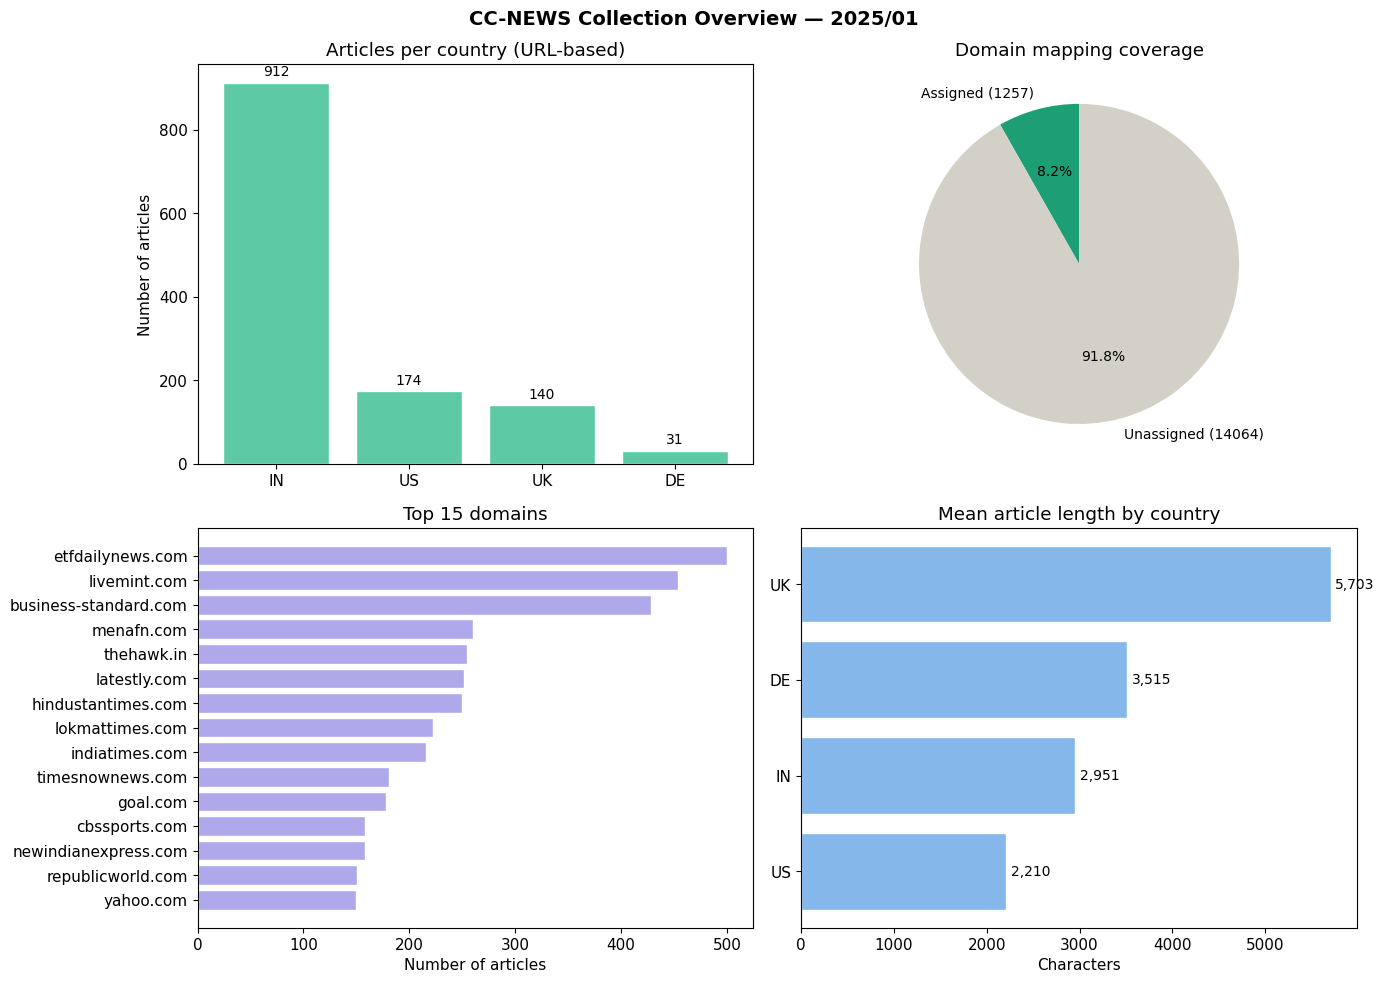

Figure saved to /content/drive/MyDrive/UNI/JLU M.Sc Data Analytics/Semester 3/Spezialisierungmodule/data/processed/


In [26]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'CC-NEWS Collection Overview — {TARGET_YEAR}/{TARGET_MONTH}', fontsize=14, fontweight='bold')

# --- 1. Articles per country ---
ax = axes[0, 0]
country_counts = df['country_url'].value_counts()
bars = ax.bar(country_counts.index, country_counts.values, color='#5DCAA5', edgecolor='white')
ax.set_title('Articles per country (URL-based)')
ax.set_ylabel('Number of articles')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha='center', va='bottom', fontsize=10)

# --- 2. Assigned vs unassigned ---
ax = axes[0, 1]
assigned = df['country_url'].notna().sum()
unassigned = df['country_url'].isna().sum()
ax.pie([assigned, unassigned],
       labels=[f'Assigned ({assigned})', f'Unassigned ({unassigned})'],
       colors=['#1D9E75', '#D3D1C7'], startangle=90,
       autopct='%1.1f%%', textprops={'fontsize': 10})
ax.set_title('Domain mapping coverage')

# --- 3. Top 15 domains ---
ax = axes[1, 0]
top_domains = df['registered_domain'].value_counts().head(15)
ax.barh(top_domains.index[::-1], top_domains.values[::-1], color='#AFA9EC', edgecolor='white')
ax.set_title('Top 15 domains')
ax.set_xlabel('Number of articles')

# --- 4. Mean article length by country ---
ax = axes[1, 1]
df['text_length'] = df['text'].str.len()
length_by_country = df.groupby('country_url')['text_length'].mean().sort_values(ascending=True)
bars = ax.barh(length_by_country.index, length_by_country.values, color='#85B7EB', edgecolor='white')
ax.set_title('Mean article length by country')
ax.set_xlabel('Characters')
for bar, val in zip(bars, length_by_country.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{DATA_PROCESSED}/collection_overview_{TARGET_YEAR}_{TARGET_MONTH}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {DATA_PROCESSED}/')

---
## 5. Next Steps

**Based on the output above:**

- Review the list of unassigned domains. High-frequency domains from English-speaking countries should be added to `DOMAIN_TO_COUNTRY` and the pipeline re-run.
- Assess country balance. If any target country has fewer than approximately 200 articles, increase `MAX_WARC_FILES` and re-run from Section 3.1. (Delete the corresponding checkpoint file first.)
- To add a second month of data, change `TARGET_YEAR` and `TARGET_MONTH` and re-run from Section 1. File names include the month, so existing checkpoints are not affected.

**Subsequent notebooks:**

- **Notebook 02 — NER + Geonames:** Extract geographic entities from article text using spaCy NER, then map them to standardised country codes using the Geonames.org database (Method 2 of 3).
- **Notebook 03 — Syntactic covariates:** Compute per-article metrics (average word length, sentence length, paragraph length) for use as regression controls.
- **Notebook 04 — Sentiment scoring:** Apply VADER and RoBERTa classifiers to all articles.

# Domain Expansion Analysis

In [37]:
# Load the English articles from Drive checkpoint
import tldextract
import pandas as pd

df_eng = pd.read_csv(f'{DATA_RAW}/articles_english_2025_01.csv')
print(f"Loaded {len(df_eng)} English articles\n")

# Extract the registered domain from each URL
# tldextract turns "https://www.bbc.co.uk/news/article123" → domain="bbc", suffix="co.uk"
# We combine them to get "bbc.co.uk"
def get_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.domain}.{ext.suffix}".lower()

df_eng['domain'] = df_eng['url'].apply(get_domain)

# Find domains NOT in our current mapping
assigned_domains = set(d.lower() for d in DOMAIN_TO_COUNTRY.keys())
unassigned = df_eng[~df_eng['domain'].isin(assigned_domains)]

# Count and show the top 50
top_unassigned = unassigned['domain'].value_counts().head(50)
print(f"Total unassigned articles: {len(unassigned)}")
print(f"Unique unassigned domains: {unassigned['domain'].nunique()}\n")
print("Top 50 unassigned domains:")
print(top_unassigned.to_string())

Loaded 15321 English articles

Total unassigned articles: 8707
Unique unassigned domains: 1136

Top 50 unassigned domains:
domain
menafn.com               260
goal.com                 178
yahoo.com                150
365project.org           149
com-unik.info             99
substack.com              95
pledgetimes.com           89
the-independent.com       89
radio.net                 86
carpages.ca               60
crimethinc.com            60
einpresswire.com          53
malaymail.com             51
mid-day.com               50
kyuk.org                  50
nation.com.pk             49
wrkf.org                  49
condesan-ecoandes.org     48
dunyanews.tv              48
wlrn.org                  47
rivals.com                46
rediff.com                45
nhl.com                   44
asianetnews.com           44
forex.com                 40
knau.org                  39
donga.com                 38
cfpublic.org              38
arynews.tv                38
kunr.org                  38


In [38]:
top_100 = unassigned['domain'].value_counts().iloc[50:100]
print("Unassigned domains ranked 51-100:")
print(top_100.to_string())

Unassigned domains ranked 51-100:
domain
nbcsandiego.com              32
zawya.com                    32
wyomingpublicmedia.org       32
pressherald.com              31
bangkokpost.com              31
dawn.com                     31
tuko.co.ke                   30
joins.com                    29
businessday.ng               29
israelnationalnews.com       29
ketr.org                     29
wuwf.org                     28
kuaf.com                     28
prnewswire.com               28
redandwhitekop.com           28
allafrica.com                27
legit.ng                     27
fbcnews.com.fj               27
newsx.com                    27
kclu.org                     27
kawc.org                     26
ctpublic.org                 26
ksut.org                     26
krgv.com                     26
delawarepublic.org           26
nhpr.org                     25
thisdaylive.com              25
wvpe.org                     25
boisestatepublicradio.org    25
upr.org                      25